# Sweep over parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import snag

from qiskit.circuit.library import efficient_su2

In [2]:
n_qubits = 3
magnetization = snag.gen_magnetization_op(n_qubits)

ansatz = efficient_su2(
    n_qubits, entanglement="circular", reps=1
)

In [3]:
field_strs = np.linspace(0., 0.5, 11)
mags = []

for field_str in field_strs:
    hamiltonian = snag.gen_hamiltonian_op(field=field_str, coupling=1.0, n_qubits=n_qubits)

    eigenvalues, eigenvectors = np.linalg.eigh(np.array(hamiltonian))
    e_gs = min(eigenvalues)

    vqe_result = snag.run_vqe(ansatz, hamiltonian, snag.compute_expectation)

    mags.append(snag.compute_expectation(vqe_result.params, ansatz, magnetization))

    print("The ground state energy is:", e_gs)
    print("VQE Error:", vqe_result.energy-e_gs)
    print("Magnetization:", mags[-1])

The ground state energy is: -3.0
VQE Error: 1.9317880628477724e-13
Magnetization: 4.353563165526708e-08
The ground state energy is: -3.0019221295943135
VQE Error: 4.7108322480671205e-05
Magnetization: -2.99906189956357
The ground state energy is: -3.007878402833891
VQE Error: 3.81732556675729e-09
Magnetization: 0.0007847556263502198
The ground state energy is: -3.018154169226941
VQE Error: 0.0025133870597815466
Magnetization: -0.0001428092117474189
The ground state energy is: -3.0330302779823355
VQE Error: 1.8054091555086416e-10
Magnetization: 3.990774722245627e-05
The ground state energy is: -3.052775637731994
VQE Error: 0.011487790288735145
Magnetization: -5.074831629980903e-06
The ground state energy is: -3.0776388834631176
VQE Error: 7.4442674247166e-12
Magnetization: 1.2871780274981148e-06
The ground state energy is: -3.107839583124694
VQE Error: 8.243672411367697e-11
Magnetization: 1.0793174589129872e-05
The ground state energy is: -3.1435595774162692
VQE Error: 3.108624468950438

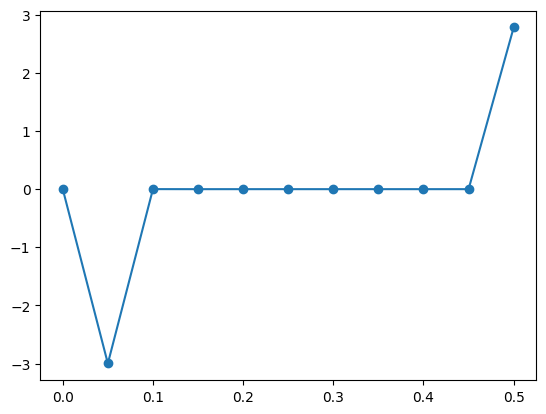

In [4]:
plt.plot(field_strs, mags, marker='o')
plt.show()